In [1]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import pearsonr

sys.path.insert(0, str(Path('..').resolve().parent))
from config.preprocess_config import T
from evaluate.micro_cond import adherence_table

Path('../../figures').mkdir(parents=True, exist_ok=True)


In [2]:
# Plot config
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

C_GEN_CA = '#A8ECFF'
C_GEN_CAFILM = '#38CFEA'
C_REAL = 'tab:blue'
C_NORMAL = 'tab:red'
MODEL_COLORS = {'ca': C_GEN_CA, 'ca-film': C_GEN_CAFILM}
MODEL_LABELS = {'ca': 'CA', 'ca-film': 'CA-Film'}

print("Plot config defined.")

Plot config defined.


In [3]:
"""
Get generated data.
"""

MODEL_DIRS = {
    'ca': Path('../../data/generated/ca'),
    'ca-film': Path('../../data/generated/ca-film'),
}

ALL_FILES = sorted(f.name for f in next(iter(MODEL_DIRS.values())).glob('*.json'))

gen_data = {}
for model, base_dir in MODEL_DIRS.items():
    gen_data[model] = {}
    for filename in ALL_FILES:
        with open(base_dir / filename) as f:
            payload = json.load(f)
        samples = np.array(payload['samples'], dtype=np.float64)
        t_tgt = payload['conditions']['trend']
        r_tgt = payload['conditions']['realized_vol']
        mean_w = t_tgt / (100.0 * T)
        var_w = (r_tgt / (100.0 ** 2) - T * mean_w ** 2) / (T - 1)
        std_w = np.sqrt(np.maximum(var_w, 1e-12))
        samples = samples * std_w + mean_w  # back to original log-return scale

        gen_data[model][filename] = {
            'n_samples': samples.shape[0],
            'trend_target': t_tgt,
            'trend_achieved': np.sum(samples * 100, axis=1),
            'rv_target': r_tgt,
            'rv_achieved': np.sum((samples * 100) ** 2, axis=1),
        }

print("Generated data loaded.")


Generated data loaded.


In [4]:
"""
3.1 - Trend adherence.
"""

print(f"{'=' * 25} Trend Adherence {'=' * 26}\n")
trend_pts = {}
for model in MODEL_DIRS:
    targets, mean_achieved = adherence_table('trend', model, gen_data, ALL_FILES)
    trend_pts[model] = (targets, mean_achieved)
    print()


========================= Trend Adherence ==========================

ca                        Target        Mean         Std     |Error|
────────────────────────────────────────────────────────────────────
t-10r100i2v15.json        -10.00     -9.9149      3.2958      0.0851
t-10r100i6v40.json        -10.00     -9.8303      2.2272      0.1697
t-10r300i2v15.json        -10.00     -9.7438      5.8273      0.2562
t-10r300i6v40.json        -10.00     -9.7479      3.0512      0.2521
t-10r500i2v15.json        -10.00     -9.8607      9.2597      0.1393
t-10r500i6v40.json        -10.00     -9.5181     21.0823      0.4819
t-10r700i2v15.json        -10.00     -9.5681     13.5677      0.4319
t-10r700i6v40.json        -10.00     -9.4852      8.5496      0.5148
t-10r900i2v15.json        -10.00     -9.5743      8.9507      0.4257
t-10r900i6v40.json        -10.00     -9.6313     20.0244      0.3687
t-20r100i2v15.json        -20.00    -19.8142      3.9424      0.1858
t-20r100i6v40.json        -20.00 

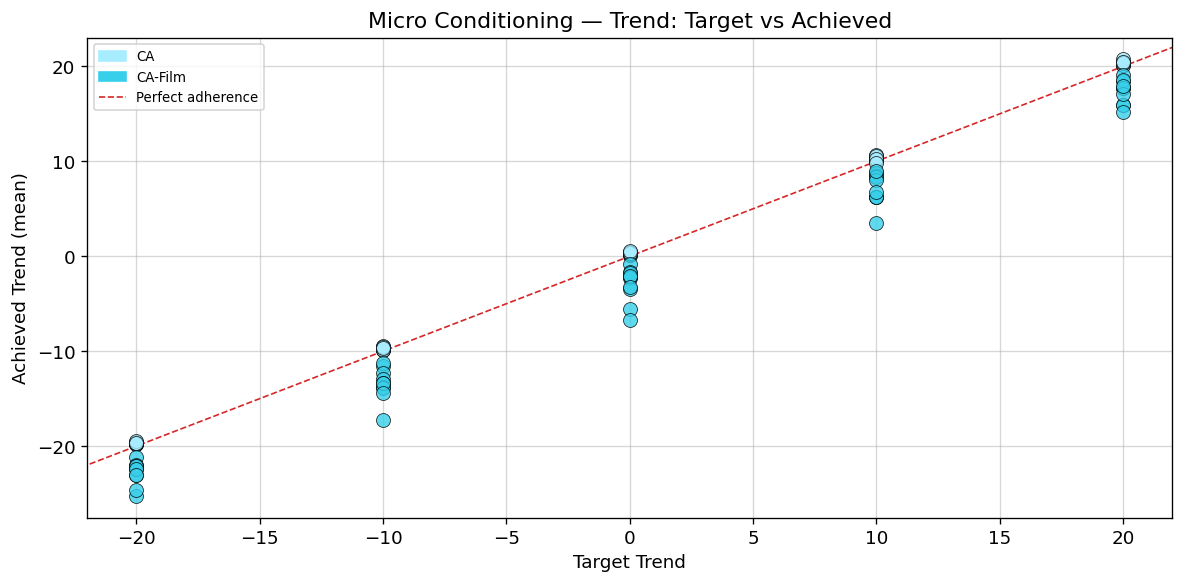

In [5]:
# Configs
fig, ax = plt.subplots(figsize=(10, 5))

# Plot
for model, (targets, mean_achieved) in trend_pts.items():
    ax.scatter(
        targets, mean_achieved,
        color=MODEL_COLORS[model], edgecolors='k', linewidths=0.5,
        s=70, alpha=0.8, zorder=3,
    )

# Plot configs
xlim = ax.get_xlim()
ylim = ax.get_ylim()
lims = [min(xlim[0], ylim[0]), max(xlim[1], ylim[1])] # Line
ax.plot(lims, lims, color=C_NORMAL, linestyle='--', linewidth=1.0, zorder=2)
ax.set_xlim(xlim)
ax.set_xlabel('Target Trend')
ax.set_ylim(ylim)
ax.set_ylabel('Achieved Trend (mean)')
ax.set_title('Micro Conditioning — Trend: Target vs Achieved')
ax.grid(alpha=0.5)
legend_handles = [
    mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]) for m in MODEL_DIRS
] + [Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Perfect adherence')]
ax.legend(handles=legend_handles, fontsize=8, loc='upper left')

# Show and save
plt.tight_layout()
plt.savefig('../../figures/conditioning_trend.png')
plt.show()


In [6]:
"""
3.2 - Realized volatility adherence.
"""

print(f"{'=' * 25} Realized Vol Adherence {'=' * 26}\n")
rv_pts = {}
for model in MODEL_DIRS:
    targets, mean_achieved = adherence_table('rv', model, gen_data, ALL_FILES)
    rv_pts[model] = (targets, mean_achieved)
    print()


========================= Realized Vol Adherence ==========================

ca                        Target        Mean         Std     |Error|
────────────────────────────────────────────────────────────────────
t-10r100i2v15.json        100.00     97.4494    130.0915      2.5506
t-10r100i6v40.json        100.00     93.4516     39.3962      6.5484
t-10r300i2v15.json        300.00    286.9396    440.7859     13.0604
t-10r300i6v40.json        300.00    279.4307    102.1229     20.5693
t-10r500i2v15.json        500.00    485.2273    783.2177     14.7727
t-10r500i6v40.json        500.00    518.2994   3238.3289     18.2994
t-10r700i2v15.json        700.00    697.6319   2177.1735      2.3681
t-10r700i6v40.json        700.00    655.3854    327.3035     44.6146
t-10r900i2v15.json        900.00    851.0197    892.0021     48.9803
t-10r900i6v40.json        900.00    879.8626   1892.0051     20.1374
t-20r100i2v15.json        100.00     96.6184    123.4008      3.3816
t-20r100i6v40.json        

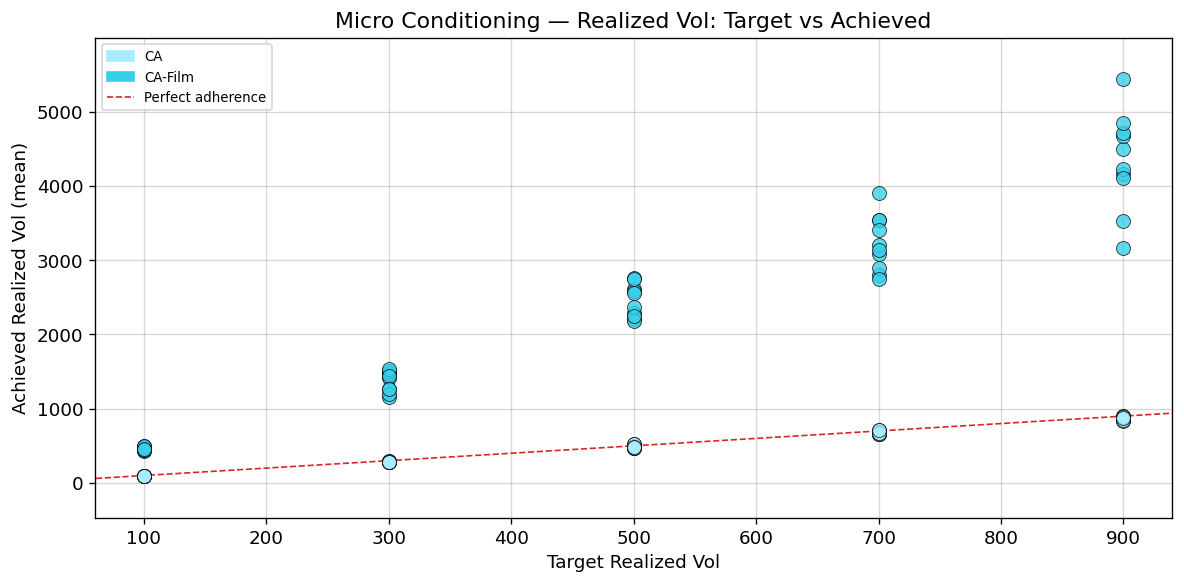

In [8]:
# Configs
fig, ax = plt.subplots(figsize=(10, 5))

# Plot
for model, (targets, mean_achieved) in rv_pts.items():
    ax.scatter(
        targets, mean_achieved,
        color=MODEL_COLORS[model], edgecolors='k', linewidths=0.5,
        s=70, alpha=0.8, zorder=3,
    )

# Plot configs
xlim = ax.get_xlim()
ylim = ax.get_ylim()
lims = [min(xlim[0], ylim[0]), max(xlim[1], ylim[1])] # Line
ax.plot(lims, lims, color=C_NORMAL, linestyle='--', linewidth=1.0, zorder=2)
ax.set_xlim(xlim)
ax.set_xlabel('Target Realized Vol')
ax.set_ylabel('Achieved Realized Vol (mean)')
ax.set_title('Micro Conditioning — Realized Vol: Target vs Achieved')
ax.grid(alpha=0.5)
legend_handles = [
    mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]) for m in MODEL_DIRS
] + [Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Perfect adherence')]
ax.legend(handles=legend_handles, fontsize=8, loc='upper left')

# Show and save
plt.tight_layout()
plt.savefig('../../figures/conditioning_rv.png')
plt.show()
